# 01 — EDA & Data Cleaning
## Nassau Candy Distributor — Product Line Profitability & Margin Performance Analysis

This notebook inspects the raw transaction data, documents data-quality issues, makes and justifies
cleaning decisions, and produces a cleaned dataset used by the rest of the project.

**Source of truth:** `data/Nassau_Candy_Distributor.xlsx` (all findings below are computed directly from this file — nothing is assumed or invented).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DATA_PATH = '../data/Nassau_Candy_Distributor.xlsx'
df = pd.read_excel(DATA_PATH)
print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns")

Loaded 10,194 rows and 18 columns


## 1. Dataset Overview

In [2]:
print("Shape:", df.shape)
print()
print("Columns:")
for c in df.columns:
    print(f"  - {c}")

Shape: (10194, 18)

Columns:
  - Row ID
  - Order ID
  - Order Date
  - Ship Date
  - Ship Mode
  - Customer ID
  - Country/Region
  - City
  - State/Province
  - Postal Code
  - Division
  - Region
  - Product ID
  - Product Name
  - Sales
  - Units
  - Gross Profit
  - Cost


In [3]:
df.dtypes

Row ID              int64
Order ID              str
Order Date         object
Ship Date          object
Ship Mode             str
Customer ID         int64
Country/Region        str
City                  str
State/Province        str
Postal Code        object
Division              str
Region                str
Product ID            str
Product Name          str
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object

In [4]:
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,2024-03-01 00:00:00,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,2024-04-01 00:00:00,2026-01-07 00:00:00,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,2024-04-01 00:00:00,2026-01-07 00:00:00,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,2024-04-01 00:00:00,2026-01-07 00:00:00,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,2024-05-01 00:00:00,2026-05-07 00:00:00,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90
5,6,US-2021-167199-CHO-SCR-58000,2024-06-01 00:00:00,2026-03-07 00:00:00,Standard Class,167199,United States,Henderson,Kentucky,42420,Chocolate,Gulf,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,32.40,9,22.50,9.90
6,7,US-2021-167199-CHO-TRI-54000,2024-06-01 00:00:00,2026-03-07 00:00:00,Standard Class,167199,United States,Henderson,Kentucky,42420,Chocolate,Gulf,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
7,8,US-2021-106054-CHO-MIL-31000,2024-06-01 00:00:00,30-06-2026,First Class,106054,United States,Athens,Georgia,30605,Chocolate,Gulf,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42
8,9,US-2021-167199-CHO-NUT-13000,2024-06-01 00:00:00,2026-03-07 00:00:00,Standard Class,167199,United States,Henderson,Kentucky,42420,Chocolate,Gulf,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,6.98,2,4.98,2.00
9,10,US-2021-167199-CHO-MIL-31000,2024-06-01 00:00:00,2026-03-07 00:00:00,Standard Class,167199,United States,Henderson,Kentucky,42420,Chocolate,Gulf,CHO-MIL-31000,Wonka Bar - Milk Chocolate,13.00,4,8.44,4.56


**Observation:** The sheet contains one transaction (order line item) per row: an order/shipping record,
a customer/location record, a product record (Division, Product ID, Product Name), and the financial
figures (Sales, Units, Gross Profit, Cost). There is a single sheet in the workbook.

## 2. Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
Row ID,0,0.0
Order ID,0,0.0
Order Date,0,0.0
Ship Date,0,0.0
Ship Mode,0,0.0
Customer ID,0,0.0
Country/Region,0,0.0
City,0,0.0
State/Province,0,0.0
Postal Code,0,0.0


**Finding:** There are **no missing values** in any of the 18 columns. No imputation is required.

## 3. Duplicate Records

In [6]:
print("Duplicate Row ID (should be 0, it's a surrogate key):", df['Row ID'].duplicated().sum())
print("Fully duplicate rows including Row ID:", df.duplicated().sum())

# Row ID is a surrogate key, so it will never look duplicated on the full-row check.
# Check for duplicates on every column EXCEPT Row ID, which is the meaningful check.
compare_cols = [c for c in df.columns if c != 'Row ID']
exact_dupes = df.duplicated(subset=compare_cols, keep='first')
print(f"Exact duplicate transaction rows (identical on all fields except Row ID): {exact_dupes.sum()}")
print(f"Sales value tied up in these duplicate rows: ${df.loc[exact_dupes, 'Sales'].sum():,.2f}")
print(f"That is {df.loc[exact_dupes, 'Sales'].sum() / df['Sales'].sum() * 100:.2f}% of total recorded Sales")

Duplicate Row ID (should be 0, it's a surrogate key): 0
Fully duplicate rows including Row ID: 0
Exact duplicate transaction rows (identical on all fields except Row ID): 313
Sales value tied up in these duplicate rows: $3,499.51
That is 2.47% of total recorded Sales


In [7]:
# Sanity check: repeated Order ID + Product ID combos are NOT automatically duplicates —
# a customer can legitimately order the same product in more than one line of the same order.
repeat_combo = df[df.duplicated(subset=['Order ID', 'Product ID'], keep=False)]
print(f"Rows sharing the same Order ID + Product ID: {len(repeat_combo)}")
repeat_combo.sort_values(['Order ID', 'Product ID']).head(6)[['Row ID', 'Order ID', 'Product ID', 'Sales', 'Units']]

Rows sharing the same Order ID + Product ID: 3018


,Row ID,Order ID,Product ID,Sales,Units
61,62,CA-2021-115238-CHO-FUD-51000,CHO-FUD-51000,18.00,5
64,65,CA-2021-115238-CHO-FUD-51000,CHO-FUD-51000,3.60,1
62,63,CA-2021-115238-CHO-MIL-31000,CHO-MIL-31000,3.25,1
65,66,CA-2021-115238-CHO-MIL-31000,CHO-MIL-31000,32.50,10
2017,2018,CA-2021-123625-CHO-MIL-31000,CHO-MIL-31000,26.00,8
2019,2020,CA-2021-123625-CHO-MIL-31000,CHO-MIL-31000,6.50,2


**Finding & decision:** 313 rows are identical across *every* column (Order ID, dates, customer, location,
product, Sales, Units, Cost, Gross Profit) except the surrogate `Row ID` — these are true duplicate records,
most plausibly caused by double data-entry or a duplicated export, representing about 2.5% of total Sales.

Separately, 3,018 rows share an Order ID + Product ID but differ in Sales/Units — these are legitimate
repeat line items within the same order and are **kept**.

**Decision:** drop the 313 exact duplicates (keeping the first occurrence), and keep everything else. This
is documented quantitatively above rather than silently dropped.

## 4. Date Columns — Order Date & Ship Date

In [8]:
for col in ['Order Date', 'Ship Date']:
    types = df[col].apply(lambda x: type(x).__name__).value_counts()
    print(col, 'cell types:')
    print(types)
    print()

Order Date cell types:
Order Date
str         6064
datetime    4130
Name: count, dtype: int64

Ship Date cell types:
Ship Date
str         6173
datetime    4021
Name: count, dtype: int64



**Finding:** Both `Order Date` and `Ship Date` are stored as a **mix of native Excel dates and text
strings** in `DD-MM-YYYY` format within the same column — a common real-world data-entry inconsistency.

In [9]:
# Are the native-datetime cells and the text-string cells really the same format?
# Native datetime cells: check the day-of-month range. If it never exceeds 12, DD/MM vs MM/DD is ambiguous
# for those specific cells (Excel serial dates themselves are unambiguous once resolved, but let's confirm
# the overall date range lines up with the text cells, which explicitly use DD-MM-YYYY).
od_dt_mask = df['Order Date'].apply(lambda x: not isinstance(x, str))
od_dt = pd.to_datetime(df.loc[od_dt_mask, 'Order Date'])
od_str = pd.to_datetime(df.loc[~od_dt_mask, 'Order Date'], format='%d-%m-%Y')

print("Order Date - native datetime cells range:", od_dt.min().date(), 'to', od_dt.max().date())
print("Order Date - text-string cells range (parsed DD-MM-YYYY):", od_str.min().date(), 'to', od_str.max().date())
print("Max day-of-month seen in native datetime cells:", od_dt.dt.day.max(), "(<=12 confirms both cell types are consistent with the same DD-MM-YYYY source data)")

Order Date - native datetime cells range: 2024-01-02 to 2025-12-12
Order Date - text-string cells range (parsed DD-MM-YYYY): 2024-01-13 to 2025-12-31
Max day-of-month seen in native datetime cells: 12 (<=12 confirms both cell types are consistent with the same DD-MM-YYYY source data)


In [10]:
sd_dt_mask = df['Ship Date'].apply(lambda x: not isinstance(x, str))
sd_dt = pd.to_datetime(df.loc[sd_dt_mask, 'Ship Date'])
sd_str = pd.to_datetime(df.loc[~sd_dt_mask, 'Ship Date'], format='%d-%m-%Y')

print("Ship Date - native datetime cells range:", sd_dt.min().date(), 'to', sd_dt.max().date())
print("Ship Date - text-string cells range (parsed DD-MM-YYYY):", sd_str.min().date(), 'to', sd_str.max().date())
print()
print("Order Date overall range:", min(od_dt.min(), od_str.min()).date(), 'to', max(od_dt.max(), od_str.max()).date())

Ship Date - native datetime cells range: 2026-01-07 to 2030-12-06
Ship Date - text-string cells range (parsed DD-MM-YYYY): 2026-06-30 to 2030-06-28

Order Date overall range: 2024-01-02 to 2025-12-31


**Data-quality issue found:** `Order Date` spans **2024-01-02 to 2025-12-31**, a plausible 2-year
transaction history. `Ship Date`, however, spans roughly **2026 to 2030** — years *after* every order was
even placed. Ship Date cannot represent a real shipping event for these orders (shipping can't happen years
after the order, and it isn't consistently ~a few days after Order Date either).

**Decision:** `Ship Date` is treated as unreliable and is **not used** for any analysis (no delivery-time or
shipping-efficiency metrics are computed). This does not affect the profitability objective, which does not
depend on Ship Date. `Order Date` is cleaned and parsed consistently (all cells → `DD-MM-YYYY` interpretation)
and used for the monthly trend analysis.

In [11]:
def parse_mixed_date(series, fmt='%d-%m-%Y'):
    is_str = series.apply(lambda x: isinstance(x, str))
    out = series.copy()
    out.loc[is_str] = pd.to_datetime(series.loc[is_str], format=fmt)
    out.loc[~is_str] = pd.to_datetime(series.loc[~is_str])
    return pd.to_datetime(out)

df['Order Date'] = parse_mixed_date(df['Order Date'])
print("Order Date parsed. New dtype:", df['Order Date'].dtype)
print("Range:", df['Order Date'].min().date(), 'to', df['Order Date'].max().date())

Order Date parsed. New dtype: datetime64[us]
Range: 2024-01-02 to 2025-12-31


## 5. Numeric Columns — Sales, Units, Cost, Gross Profit

In [12]:
df[['Sales', 'Units', 'Cost', 'Gross Profit']].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,10194.0,13.908537,11.341020,1.25,7.2,10.80,18.00,260.0
Units,10194.0,3.791838,2.228317,1.00,2.0,3.00,5.00,14.0
Cost,10194.0,4.742087,5.061647,0.60,2.4,3.60,5.70,130.0
Gross Profit,10194.0,9.166451,6.643740,0.25,4.9,7.47,12.25,130.0


In [13]:
print("Negative Sales:", (df['Sales'] < 0).sum())
print("Zero Sales:", (df['Sales'] == 0).sum())
print("Negative Units:", (df['Units'] < 0).sum())
print("Zero Units:", (df['Units'] == 0).sum())
print("Negative Cost:", (df['Cost'] < 0).sum())
print("Zero Cost:", (df['Cost'] == 0).sum())
print("Negative Gross Profit:", (df['Gross Profit'] < 0).sum())
print("Zero Gross Profit:", (df['Gross Profit'] == 0).sum())

Negative Sales: 0
Zero Sales: 0
Negative Units: 0
Zero Units: 0
Negative Cost: 0
Zero Cost: 0
Negative Gross Profit: 0
Zero Gross Profit: 0


**Finding:** No negative or zero values in Sales, Units, Cost, or Gross Profit. Every transaction
represents a genuine, positive sale — no cleaning needed for invalid numeric records.

## 6. Validating Gross Profit = Sales − Cost

In [14]:
residual = df['Sales'] - df['Cost'] - df['Gross Profit']
print("Residual (Sales - Cost - Gross Profit) summary:")
print(residual.describe())
print()
print("Max absolute residual:", residual.abs().max())
print("Rows where |residual| > 1 cent:", (residual.abs() > 0.01).sum())

Residual (Sales - Cost - Gross Profit) summary:
count    1.019400e+04
mean     3.609913e-16
std      8.618580e-16
min     -7.105427e-15
25%      0.000000e+00
50%      0.000000e+00
75%      8.881784e-16
max      3.552714e-15
dtype: float64



Max absolute residual: 7.105427357601002e-15
Rows where |residual| > 1 cent: 0


**Finding:** `Gross Profit` already exists in the source data, and it is confirmed (to within
floating-point rounding, max residual ~7e-15) to equal `Sales − Cost` for **every single row**. The existing
Gross Profit column is validated and used as-is — it is not recreated.

## 7. Product, Division & Region Structure

In [15]:
print("Unique Product IDs:", df['Product ID'].nunique())
print("Unique Product Names:", df['Product Name'].nunique())
print("Product ID <-> Product Name is 1:1:",
      (df.groupby('Product ID')['Product Name'].nunique() == 1).all() and
      (df.groupby('Product Name')['Product ID'].nunique() == 1).all())
print()
df[['Product ID', 'Product Name']].drop_duplicates().sort_values('Product ID').reset_index(drop=True)

Unique Product IDs: 15
Unique Product Names: 15
Product ID <-> Product Name is 1:1: True



,Product ID,Product Name
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows
1,CHO-MIL-31000,Wonka Bar - Milk Chocolate
2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise
3,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious
4,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel
5,OTH-FIZ-56000,Fizzy Lifting Drinks
6,OTH-GUM-21000,Wonka Gum
7,OTH-KAZ-38000,Kazookles
8,OTH-LIC-15000,Lickable Wallpaper
9,SUG-EVE-47000,Everlasting Gobstopper


In [16]:
df['Division'].value_counts()

Division
Chocolate    9844
Other         310
Sugar          40
Name: count, dtype: int64

In [17]:
df['Region'].value_counts()

Region
Pacific     3253
Atlantic    2986
Interior    2335
Gulf        1620
Name: count, dtype: int64

In [18]:
df['Country/Region'].value_counts()

Country/Region
United States    9994
Canada            200
Name: count, dtype: int64

In [19]:
# Product ID prefix vs Division sanity check
df['_prefix'] = df['Product ID'].str.split('-').str[0]
prefix_div = df.groupby('Division')['_prefix'].unique()
print(prefix_div)
df.drop(columns='_prefix', inplace=True)

Division
Chocolate         [CHO]
Other             [OTH]
Sugar        [OTH, SUG]
Name: _prefix, dtype: object


**Findings:**
- 15 distinct products across 3 divisions: **Chocolate** (9,844 rows, ~96.6%), **Other** (310 rows), **Sugar**
  (40 rows). The division mix is heavily skewed toward Chocolate.
- Product ID and Product Name map 1:1 — no naming inconsistencies to reconcile.
- One product, *Fizzy Lifting Drinks*, uses an `OTH-` ID prefix but is labeled Division = **Sugar** in every
  one of its 6 occurrences. This is a labeling quirk in the ID scheme, not a data error (it's fully
  consistent), so it is left as-is and the `Division` column (not the ID prefix) is treated as the source of
  truth for divisional grouping throughout this project.
- 4 regions (Pacific, Atlantic, Interior, Gulf) and 2 countries (United States, Canada — 9,994 vs 200 rows).

## 8. Note on the Original Project Brief

The original brief mentioned factory coordinates, product/factory correlation, and shipping-route
efficiency. **This dataset contains no factory location, coordinate, or route data of any kind** — only
customer-side City/State/Postal Code/Region/Country. Ship Date is also unreliable (see Section 4). Per the
actual project objective (product line profitability), that thread is correctly left out rather than
fabricated or forced in.

## 9. Apply Cleaning & Save Cleaned Dataset

In [20]:
df_clean = df.copy()

before = len(df_clean)
compare_cols = [c for c in df_clean.columns if c != 'Row ID']
df_clean = df_clean.drop_duplicates(subset=compare_cols, keep='first').reset_index(drop=True)
after = len(df_clean)
print(f"Dropped {before - after} exact duplicate rows ({before:,} -> {after:,})")

df_clean['Order Year'] = df_clean['Order Date'].dt.year
df_clean['Order Month'] = df_clean['Order Date'].dt.month
df_clean['Order Year-Month'] = df_clean['Order Date'].dt.to_period('M').astype(str)

df_clean = df_clean.drop(columns=['Ship Date'])  # excluded — see Section 4

print()
print("Final cleaned shape:", df_clean.shape)
df_clean.head()

Dropped 313 exact duplicate rows (10,194 -> 9,881)



Final cleaned shape: (9881, 20)


,Row ID,Order ID,Order Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Order Year,Order Month,Order Year-Month
0,1,US-2021-103800-CHO-MIL-31000,2024-03-01,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,2024,3,2024-03
1,2,US-2021-112326-CHO-TRI-54000,2024-04-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,2024,4,2024-04
2,3,US-2021-112326-CHO-NUT-13000,2024-04-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,2024,4,2024-04
3,4,US-2021-112326-CHO-SCR-58000,2024-04-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,2024,4,2024-04
4,5,US-2021-141817-CHO-TRI-54000,2024-05-01,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,2024,5,2024-05


In [21]:
import os
os.makedirs('../data', exist_ok=True)
df_clean.to_csv('../data/cleaned_transactions.csv', index=False)
print("Saved ../data/cleaned_transactions.csv")

Saved ../data/cleaned_transactions.csv


## 10. EDA Visualizations

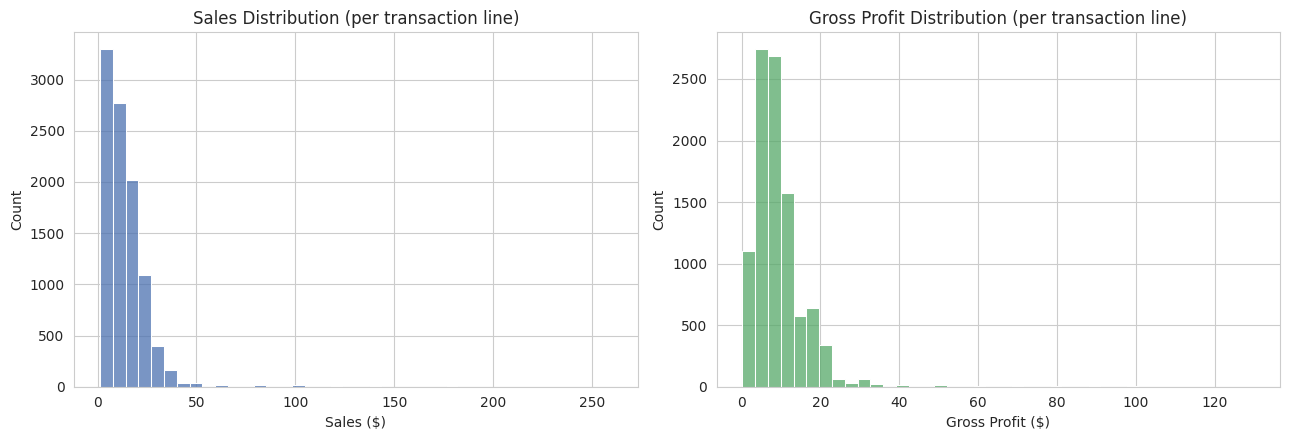

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df_clean['Sales'], bins=40, color='#4C72B0', ax=axes[0])
axes[0].set_title('Sales Distribution (per transaction line)')
axes[0].set_xlabel('Sales ($)')
sns.histplot(df_clean['Gross Profit'], bins=40, color='#55A868', ax=axes[1])
axes[1].set_title('Gross Profit Distribution (per transaction line)')
axes[1].set_xlabel('Gross Profit ($)')
plt.tight_layout()
plt.savefig('../images/dist_sales_profit.png', dpi=120)
plt.show()

**Interpretation:** Both Sales and Gross Profit per line item are right-skewed — most transaction
lines are small-dollar, with a long tail of larger orders. Median Sales per line (~$10.80) is well below the
mean (~$13.9), confirming the skew.

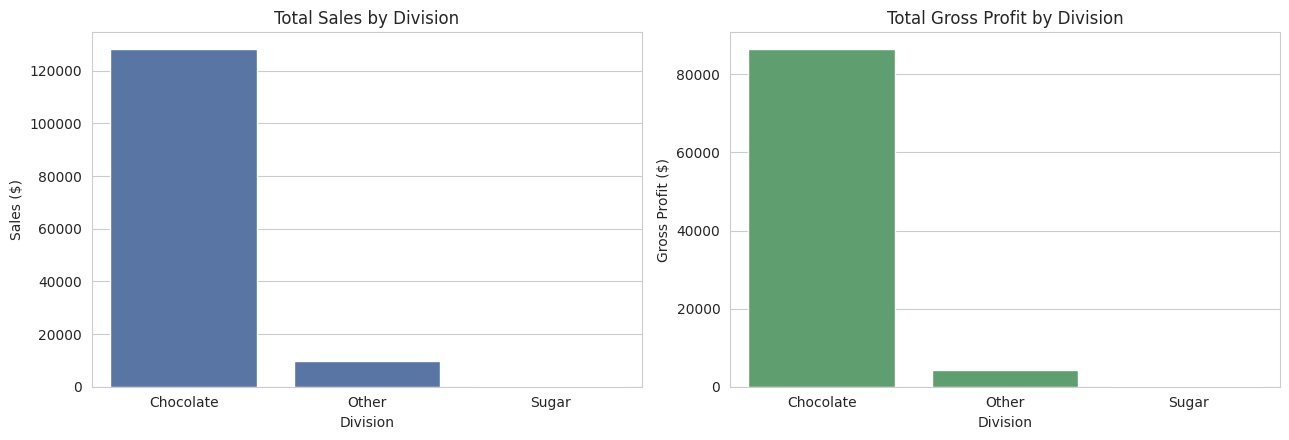

,Sales,Gross Profit
Division,,
Chocolate,128193.39,86458.23
Other,9663.25,4333.45
Sugar,427.48,284.73


In [23]:
div_agg = df_clean.groupby('Division')[['Sales', 'Gross Profit']].sum().sort_values('Sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=div_agg.index, y=div_agg['Sales'], ax=axes[0], color='#4C72B0')
axes[0].set_title('Total Sales by Division')
axes[0].set_ylabel('Sales ($)')
sns.barplot(x=div_agg.index, y=div_agg['Gross Profit'], ax=axes[1], color='#55A868')
axes[1].set_title('Total Gross Profit by Division')
axes[1].set_ylabel('Gross Profit ($)')
plt.tight_layout()
plt.savefig('../images/division_sales_profit.png', dpi=120)
plt.show()
div_agg

**Interpretation:** Chocolate dominates both Sales and Gross Profit, consistent with it being ~96.6%
of transaction volume. Other and Sugar divisions are minor contributors by absolute dollars — their
per-unit performance is examined properly (margin, not just volume) in Notebook 3.

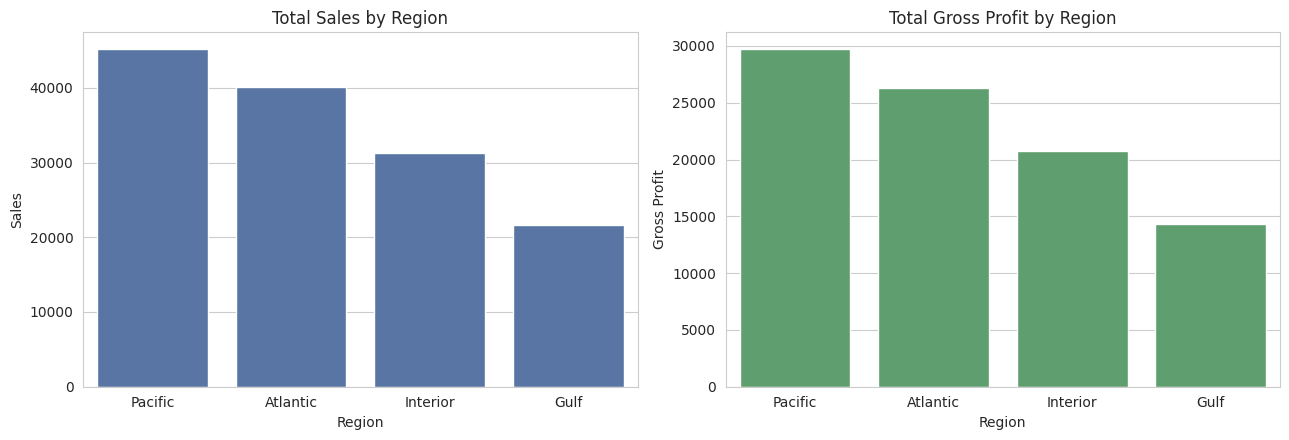

,Sales,Gross Profit
Region,,
Pacific,45164.98,29716.11
Atlantic,40153.42,26269.30
Interior,31284.12,20770.57
Gulf,21681.60,14320.43


In [24]:
reg_agg = df_clean.groupby('Region')[['Sales', 'Gross Profit']].sum().sort_values('Sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=reg_agg.index, y=reg_agg['Sales'], ax=axes[0], color='#4C72B0')
axes[0].set_title('Total Sales by Region')
sns.barplot(x=reg_agg.index, y=reg_agg['Gross Profit'], ax=axes[1], color='#55A868')
axes[1].set_title('Total Gross Profit by Region')
plt.tight_layout()
plt.savefig('../images/region_sales_profit.png', dpi=120)
plt.show()
reg_agg

**Interpretation:** Pacific and Atlantic are the largest regions by both Sales and Gross Profit, followed by Interior and Gulf.

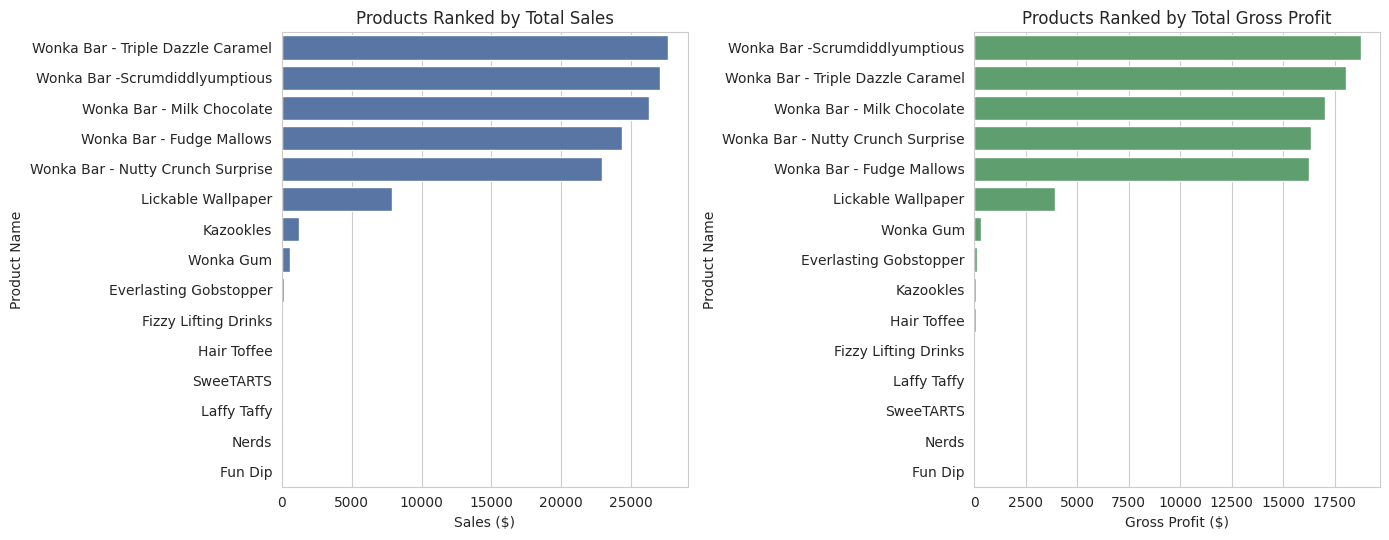

In [25]:
top_sales = df_clean.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)
top_profit = df_clean.groupby('Product Name')['Gross Profit'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.barplot(x=top_sales.values, y=top_sales.index, ax=axes[0], color='#4C72B0')
axes[0].set_title('Products Ranked by Total Sales')
axes[0].set_xlabel('Sales ($)')
sns.barplot(x=top_profit.values, y=top_profit.index, ax=axes[1], color='#55A868')
axes[1].set_title('Products Ranked by Total Gross Profit')
axes[1].set_xlabel('Gross Profit ($)')
plt.tight_layout()
plt.savefig('../images/top_products.png', dpi=120)
plt.show()

**Interpretation:** The ranking by Sales and the ranking by Gross Profit are not identical — a first
signal that sales volume alone doesn't determine profitability, which is explored formally with margin
metrics in Notebook 2.

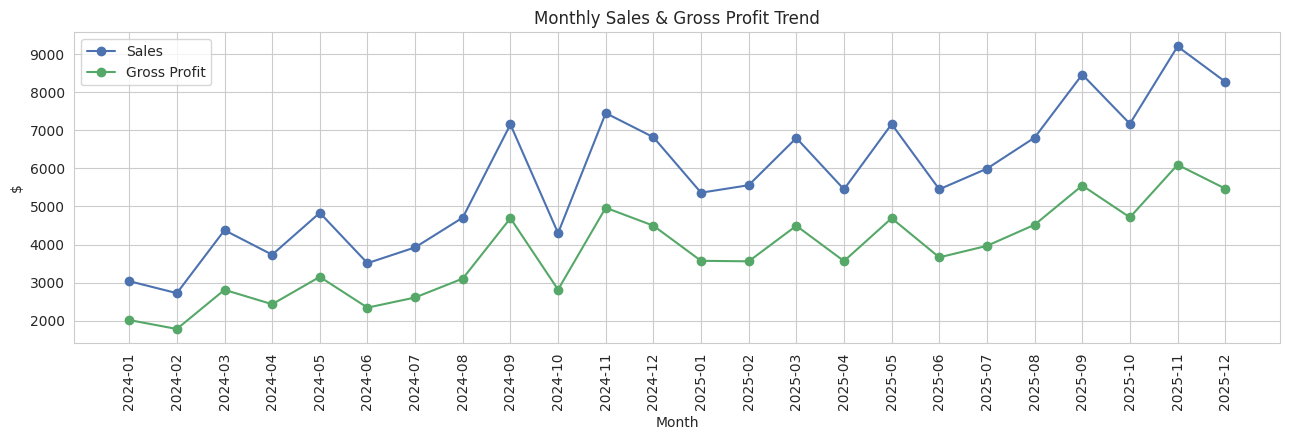

In [26]:
monthly = df_clean.groupby('Order Year-Month')[['Sales', 'Gross Profit']].sum().sort_index()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(monthly.index, monthly['Sales'], marker='o', label='Sales', color='#4C72B0')
ax.plot(monthly.index, monthly['Gross Profit'], marker='o', label='Gross Profit', color='#55A868')
ax.set_title('Monthly Sales & Gross Profit Trend')
ax.set_xlabel('Month')
ax.set_ylabel('$')
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../images/monthly_trend.png', dpi=120)
plt.show()

**Interpretation:** Sales and Gross Profit move closely together month to month, as expected since margin is fairly stable across the two-year window (verified formally in Notebook 2's margin-volatility check).

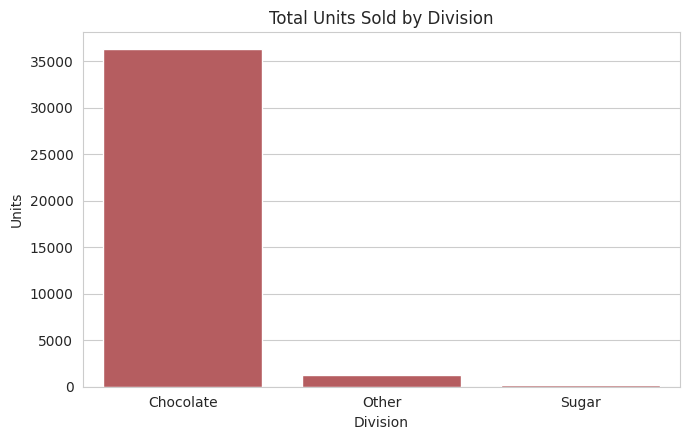

Division
Chocolate    36288
Other         1242
Sugar          137
Name: Units, dtype: int64

In [27]:
units_agg = df_clean.groupby('Division')['Units'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(x=units_agg.index, y=units_agg.values, color='#C44E52', ax=ax)
ax.set_title('Total Units Sold by Division')
ax.set_ylabel('Units')
plt.tight_layout()
plt.savefig('../images/units_by_division.png', dpi=120)
plt.show()
units_agg

## 11. Notebook 1 Summary

**Data quality findings:**
- No missing values across any of the 18 original columns.
- 313 exact duplicate transaction rows found and removed (~2.5% of total Sales dollars).
- `Order Date` mixed native-date and text-string cells in the same column; parsed to a consistent
  datetime (2024-01-02 to 2025-12-31).
- `Ship Date` is unreliable (dates fall years after the corresponding Order Date) and was excluded from
  analysis entirely.
- `Gross Profit` already existed in the source and was validated as exactly `Sales − Cost` for all rows —
  not recreated.
- No negative, zero, or otherwise invalid Sales/Units/Cost/Gross Profit values.
- 15 products across 3 divisions (Chocolate, Other, Sugar) and 4 regions (Pacific, Atlantic, Interior, Gulf); Division is heavily skewed toward Chocolate (~96.6% of rows).
- No factory/coordinate/shipping-route data exists in this dataset — that portion of the original brief is out of scope for this data and is not fabricated.

**Output:** `data/cleaned_transactions.csv` — 9,881 clean, de-duplicated transaction rows with a parsed
`Order Date`, `Order Year`, `Order Month`, and `Order Year-Month`, ready for profitability analysis in
Notebook 2.